Confusion Matrix:
 [[ 57   6]
 [  2 106]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.97      0.90      0.93        63
      benign       0.95      0.98      0.96       108

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171

Accuracy: 0.9532


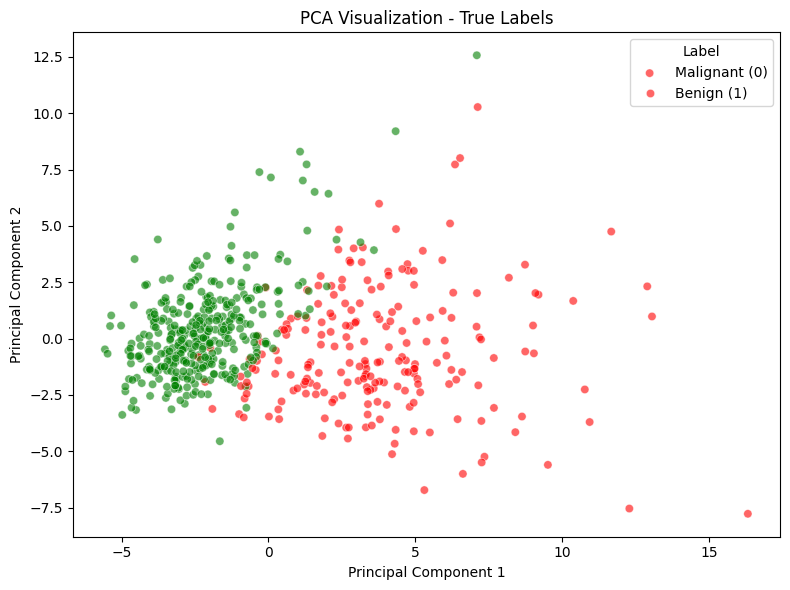

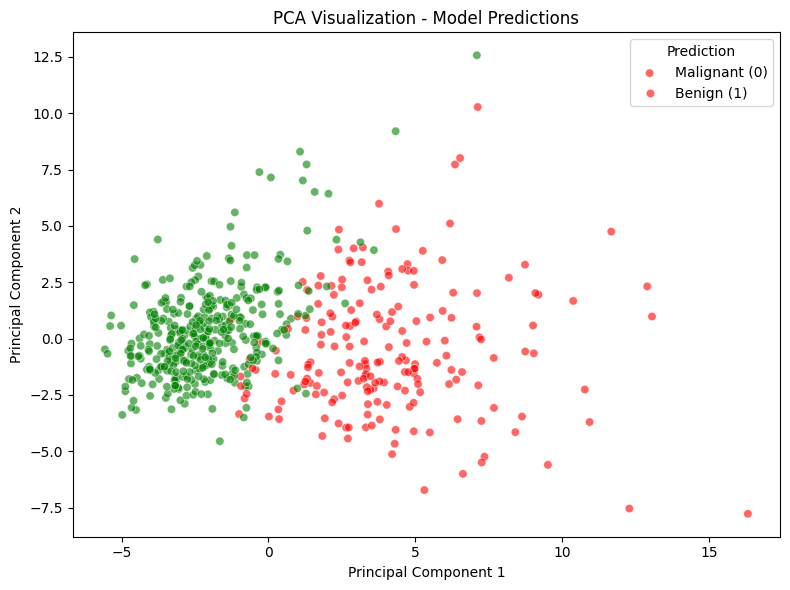

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

# === 1. Load dataset ===
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)  # 0 = malignant, 1 = benign

# === 2. Standardize features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 3. Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# === 4. Linear Regression ===
lr = LinearRegression()
lr.fit(X_train, y_train)

# === 5. Predict and convert to binary ===
y_pred_continuous = lr.predict(X_test)
y_pred_binary = np.where(y_pred_continuous >= 0.5, 1, 0)

# === 6. Evaluation ===
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_binary))
print("\nClassification Report:\n", classification_report(y_test, y_pred_binary, target_names=["malignant", "benign"]))
print(f"Accuracy: {accuracy_score(y_test, y_pred_binary):.4f}")

# === 7. PCA Visualization ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette=["red", "green"], alpha=0.6)
plt.title("PCA Visualization of Breast Cancer Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Label", labels=["Malignant (0)", "Benign (1)"])
plt.tight_layout()
plt.show()
